In [1]:
# -------------------- Basic Libraries --------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import emoji

# -------------------- PyTorch --------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- Transformers --------------------
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    pipeline
)

# -------------------- Sklearn --------------------
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
!pip install optuna
import optuna

# -------------------- Imbalanced Data --------------------
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# -------------------- Visualization --------------------
from wordcloud import WordCloud

# -------------------- FastAPI --------------------
from fastapi import FastAPI, HTTPException
import uvicorn
import nest_asyncio
from pydantic import BaseModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 14.8 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/content/sample_data/file.csv")
df.head()

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,1,"Try talking with ChatGPT, our new AI system wh...",good
2,2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,3,"THRILLED to share that ChatGPT, our new model ...",good
4,4,"As of 2 minutes ago, @OpenAI released their ne...",bad


In [3]:
df['labels'].value_counts()

,count
labels,
bad,107796
good,56011
neutral,55487


In [4]:
df.dropna(how='any', axis=0, inplace=True)

In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
tweets,0
labels,0


In [6]:
label_map = {
    "bad": 0,
    "neutral": 1,
    "good": 2
}

df["labels"] = df["labels"].str.lower().map(label_map)
df.head()

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,1
1,1,"Try talking with ChatGPT, our new AI system wh...",2
2,2,ChatGPT: Optimizing Language Models for Dialog...,1
3,3,"THRILLED to share that ChatGPT, our new model ...",2
4,4,"As of 2 minutes ago, @OpenAI released their ne...",0


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)             # remove mentions
    text = re.sub(r"#\w+", "", text)             # remove hashtags
    #text = emoji.replace_emoji(text, replace="")# remove emojis
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df["tweets"] = df["tweets"].apply(clean_text)

/tmp/ipython-input-521367866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["labels"], palette="Set2")


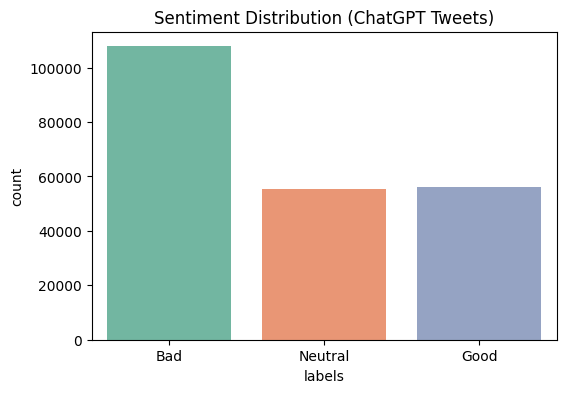

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["labels"], palette="Set2")
plt.xticks([0,1,2], ["Bad","Neutral","Good"])
plt.title("Sentiment Distribution (ChatGPT Tweets)")
plt.show()

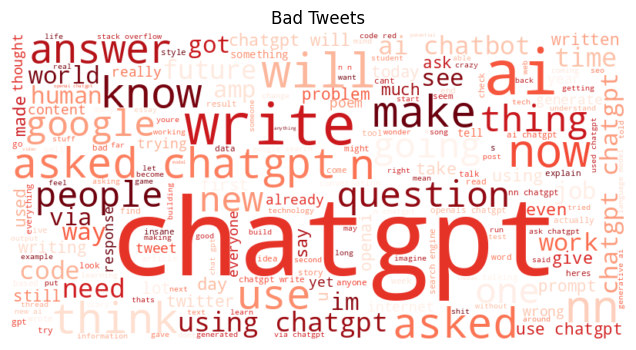

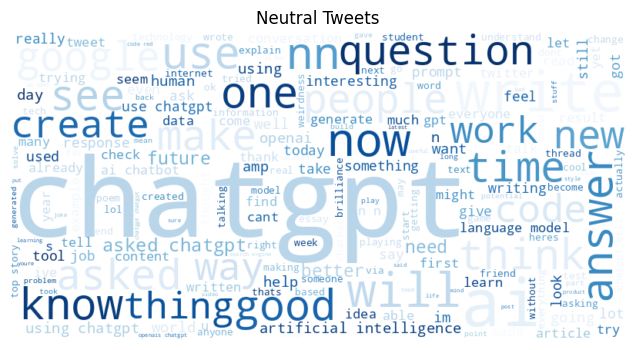

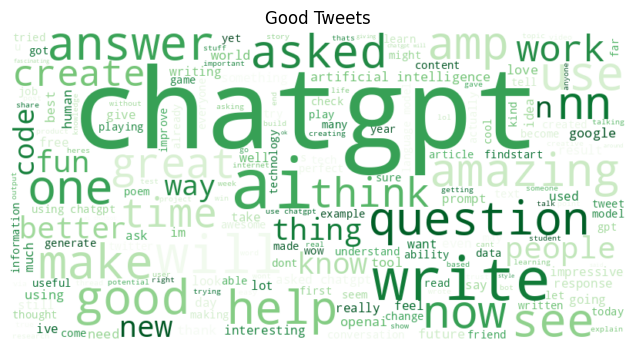

In [9]:
def plot_wordcloud(texts, title, cmap):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=cmap
    ).generate(" ".join(texts))

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(df[df.labels==0]["tweets"], "Bad Tweets", "Reds")
plot_wordcloud(df[df.labels==1]["tweets"], "Neutral Tweets", "Blues")
plot_wordcloud(df[df.labels==2]["tweets"], "Good Tweets", "Greens")

In [10]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["tweets"],
    df["labels"],
    test_size=0.3,
    stratify=df["labels"],
    random_state=42
)

In [11]:
##########################################################################################################

In [12]:
# Create 50K subset with class balance
train_subset, _, label_subset, _ = train_test_split(
    train_texts,
    train_labels,
    train_size=50000,
    stratify=train_labels,
    random_state=42
)

print(len(train_subset), len(label_subset))

50000 50000


In [13]:
def objective(trial):

    # Better ngram tuning
    ngram_choice = trial.suggest_int("ngram", 1, 2)
    ngram_range = (1, ngram_choice)

    # Cleaner max_features
    max_features = trial.suggest_categorical(
        "max_features",
        [3000, 5000, 7000, 9000]
    )

    C = trial.suggest_float("C", 0.01, 100, log=True)
    k_neighbors = trial.suggest_int("k_neighbors", 3, 7)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=ngram_range,
            max_features=max_features,
            stop_words="english"
        )),
        ("smote", SMOTE(
            k_neighbors=k_neighbors,
            random_state=42
        )),
        ("clf", LogisticRegression(
            C=C,
            max_iter=1000,
            solver="liblinear"
        ))
    ])

    score = cross_val_score(
        pipeline,
        train_subset,
        label_subset,
        cv=3,                 # faster than 5
        scoring="f1_weighted",
        n_jobs=-1
    )

    return score.mean()

In [14]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-02-22 04:59:11,823] A new study created in memory with name: no-name-8ffd7c0b-48d7-4850-8534-e3a5f84044d7
[I 2026-02-22 04:59:30,771] Trial 0 finished with value: 0.673292816861475 and parameters: {'ngram': 2, 'max_features': 5000, 'C': 0.08699779752761257, 'k_neighbors': 4}. Best is trial 0 with value: 0.673292816861475.
[I 2026-02-22 04:59:49,899] Trial 1 finished with value: 0.7210772041590895 and parameters: {'ngram': 2, 'max_features': 9000, 'C': 4.517096562320205, 'k_neighbors': 7}. Best is trial 1 with value: 0.7210772041590895.
[I 2026-02-22 05:00:06,623] Trial 2 finished with value: 0.7197014694941002 and parameters: {'ngram': 2, 'max_features': 9000, 'C': 6.660305429238581, 'k_neighbors': 4}. Best is trial 1 with value: 0.7210772041590895.
[I 2026-02-22 05:00:20,009] Trial 3 finished with value: 0.7285732968283399 and parameters: {'ngram': 1, 'max_features': 5000, 'C': 74.05597575388798, 'k_neighbors': 3}. Best is trial 3 with value: 0.7285732968283399.
[I 2026-02-22 

Best Score: 0.7309569753317692
Best Params: {'ngram': 1, 'max_features': 3000, 'C': 42.40713366323066, 'k_neighbors': 6}


In [15]:
best_params = study.best_params

final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, best_params["ngram"]),
        max_features=best_params["max_features"],
        stop_words="english"
    )),
    ("smote", SMOTE(
        k_neighbors=best_params["k_neighbors"],
        random_state=42
    )),
    ("clf", LogisticRegression(
        C=best_params["C"],
        max_iter=1000,
        solver="liblinear"
    ))
])

# train on FULL data
final_model.fit(train_texts, train_labels)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=3000, stop_words='english')),
                ('smote', SMOTE(k_neighbors=6, random_state=42)),
                ('clf',
                 LogisticRegression(C=42.40713366323066, max_iter=1000,
                                    solver='liblinear'))])

In [16]:
val_preds = final_model.predict(val_texts)

print(classification_report(val_labels, val_preds))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     32339
           1       0.62      0.57      0.59     16646
           2       0.73      0.76      0.75     16804

    accuracy                           0.78     65789
   macro avg       0.74      0.74      0.74     65789
weighted avg       0.77      0.78      0.77     65789



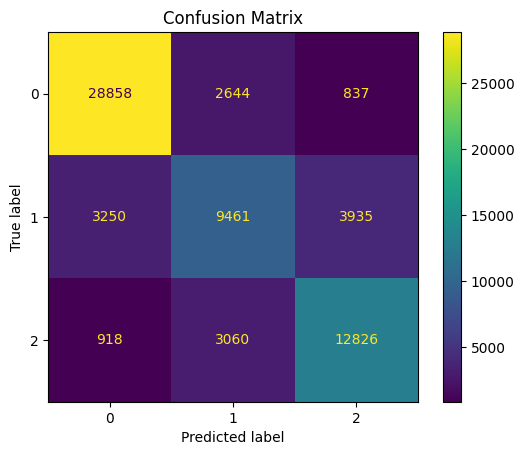

In [17]:
cm = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=final_model.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

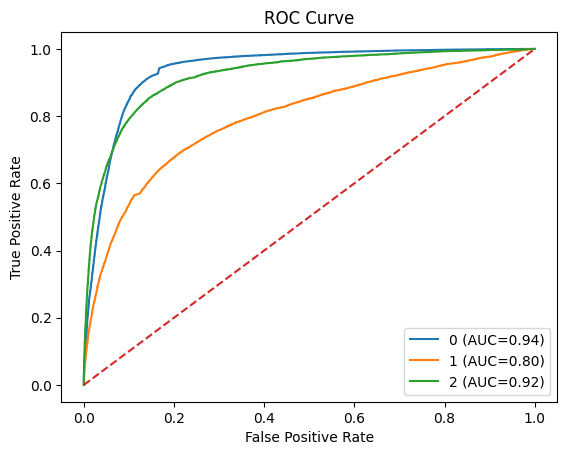

In [18]:
y_prob = final_model.predict_proba(val_texts)

classes = final_model.classes_
y_test_bin = label_binarize(val_labels, classes=classes)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

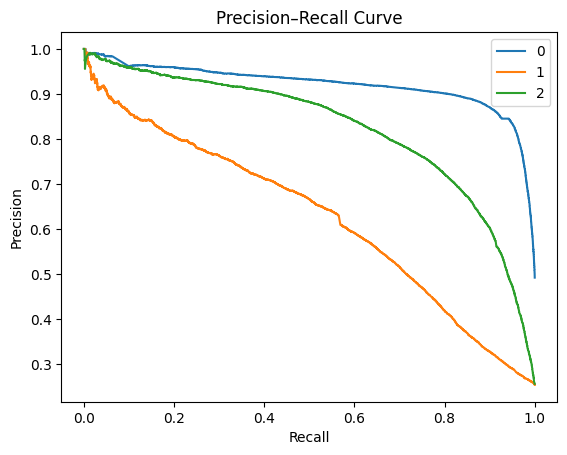

In [19]:
plt.figure()

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )
    plt.plot(recall, precision, label=classes[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

In [20]:
#########################################################################################

In [21]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    output_attentions=True
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding=True,
            max_length=96
        )
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [24]:
train_loader = DataLoader(
    SentimentDataset(train_texts, train_labels),
    batch_size=16,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    SentimentDataset(val_texts, val_labels),
    batch_size=16,
    pin_memory=True
)

In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
EPOCHS = 3

train_loss_history = []
val_loss_history = []

In [26]:
for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for batch in train_loader:
        optimizer.zero_grad()
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss_history.append(np.mean(train_losses))

    model.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k:v.to(device) for k,v in batch.items()}
            outputs = model(**batch)
            val_losses.append(outputs.loss.item())

    val_loss_history.append(np.mean(val_losses))

    print(f"Epoch {epoch+1} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {val_loss_history[-1]:.4f}")

Epoch 1 | Train Loss: 0.3562 | Val Loss: 0.2357
Epoch 2 | Train Loss: 0.1992 | Val Loss: 0.1892
Epoch 3 | Train Loss: 0.1487 | Val Loss: 0.1743


In [ ]:
'''Epoch 1 → Train 0.3562 | Val 0.2357
Epoch 2 → Train 0.1992 | Val 0.1892
Epoch 3 → Train 0.1487 | Val 0.1743
Epoch 4 → Train 0.1527 | Val 0.1708
Epoch 5 → Train 0.1491 | Val 0.1715'''

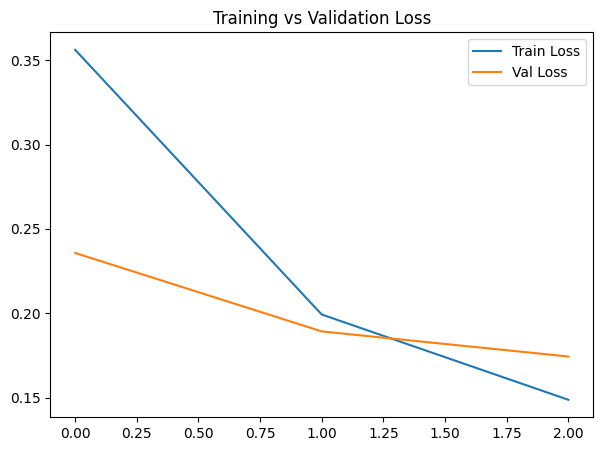

In [27]:
plt.figure(figsize=(7,5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [28]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        inputs = {k:v.to(device) for k,v in batch.items() if k!="labels"}
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(batch["labels"].numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=["Bad","Neutral","Good"]
))

              precision    recall  f1-score   support

         Bad       0.97      0.96      0.97     32339
     Neutral       0.90      0.86      0.88     16646
        Good       0.90      0.96      0.93     16804

    accuracy                           0.94     65789
   macro avg       0.93      0.93      0.93     65789
weighted avg       0.94      0.94      0.94     65789



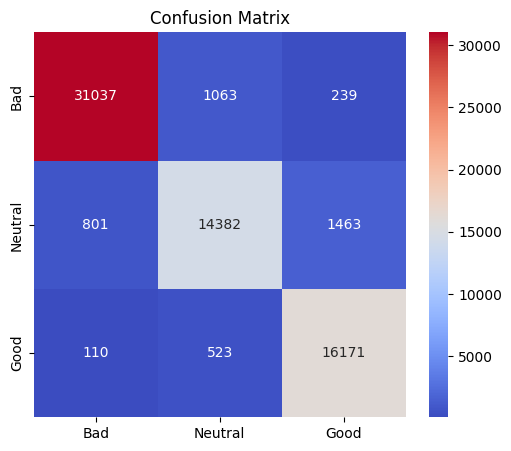

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Bad","Neutral","Good"],
    yticklabels=["Bad","Neutral","Good"]
)
plt.title("Confusion Matrix")
plt.show()

In [30]:
def plot_attention_heatmap(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attention = outputs.attentions[-1][0].mean(dim=0).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    plt.figure(figsize=(10,8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="magma")
    plt.xticks(rotation=90)
    plt.title("Attention Heatmap")
    plt.show()

In [31]:
def predict_with_visual(text):
    text = clean_text(text)
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    labels = ["Bad","Neutral","Good"]

    plt.figure(figsize=(6,4))
    plt.bar(labels, probs, color="magenta")
    plt.ylim(0,1)
    plt.title("Sentiment Probability")
    plt.show()

    return labels[np.argmax(probs)], probs

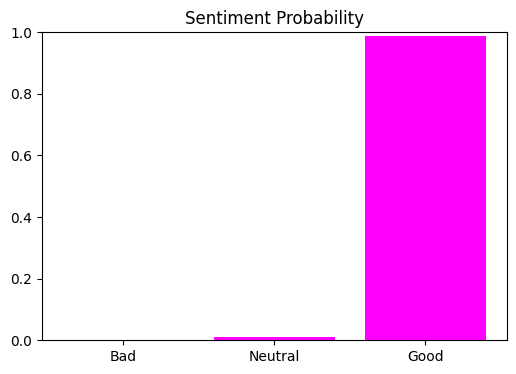

Sentiment: Good
Probabilities: [0.00101412 0.01155397 0.987432  ]


In [32]:
chat = "ChatGPT has significantly improved my productivity. It gives accurate answers,understands context very well, and helps me debug code faster than before."

text = clean_text(chat)
sentiment, probs = predict_with_visual(text)

print("Sentiment:", sentiment)
print("Probabilities:", probs)

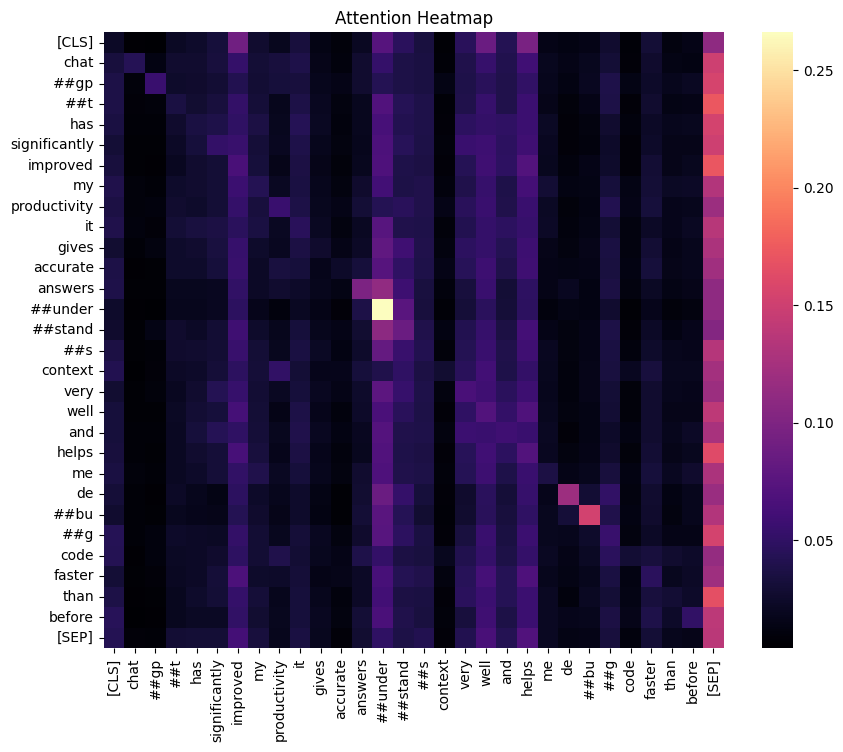

In [33]:
plot_attention_heatmap(text)

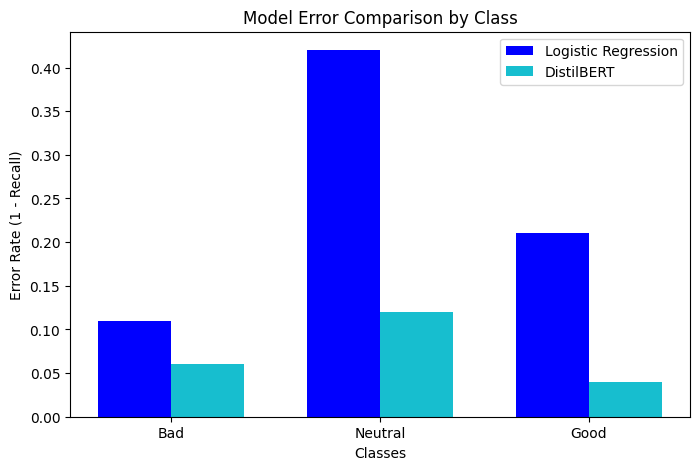

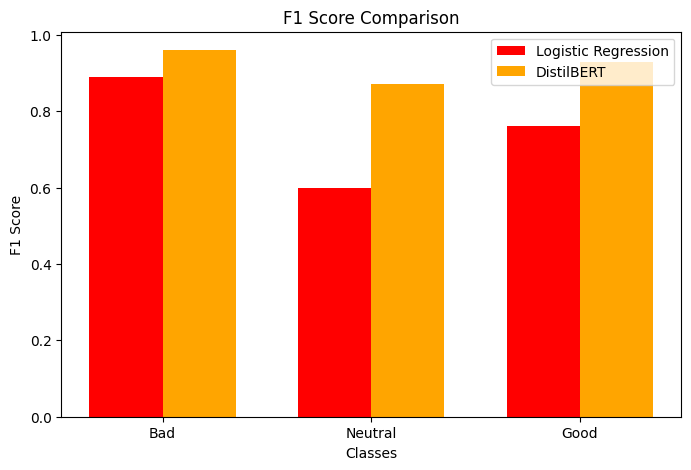

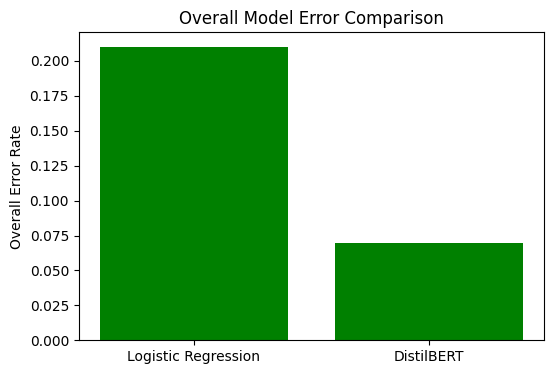

In [36]:

# -----------------------------
# 1. DEFINE METRICS (from your results)
# -----------------------------

classes = ["Bad", "Neutral", "Good"]

# Logistic Regression metrics
lr_precision = [0.89, 0.63, 0.73]
lr_recall = [0.89, 0.58, 0.79]
lr_f1 = [0.89, 0.60, 0.76]
lr_accuracy = 0.79

# DistilBERT metrics
bert_precision = [0.98, 0.87, 0.90]
bert_recall = [0.94, 0.88, 0.96]
bert_f1 = [0.96, 0.87, 0.93]
bert_accuracy = 0.93

# Convert recall → error rate
lr_error = [1 - x for x in lr_recall]
bert_error = [1 - x for x in bert_recall]

x = np.arange(len(classes))
width = 0.35


# -----------------------------
# 2. ERROR RATE COMPARISON
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_error, width, label="Logistic Regression", color="blue")
plt.bar(x + width/2, bert_error, width, label="DistilBERT", color="#17becf" )

plt.xlabel("Classes")
plt.ylabel("Error Rate (1 - Recall)")
plt.title("Model Error Comparison by Class")
plt.xticks(x, classes)
plt.legend()
plt.show()


# -----------------------------
# 3. F1 SCORE COMPARISON
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_f1, width, label="Logistic Regression", color="red")
plt.bar(x + width/2, bert_f1, width, label="DistilBERT", color="orange")

plt.xlabel("Classes")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.xticks(x, classes)
plt.legend()
plt.show()


# -----------------------------
# 4. OVERALL ERROR COMPARISON
# -----------------------------
models = ["Logistic Regression", "DistilBERT"]
overall_error = [1 - lr_accuracy, 1 - bert_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, overall_error, color="green")
plt.ylabel("Overall Error Rate")
plt.title("Overall Model Error Comparison")
plt.show()

In [37]:
######### AB Testing #############

In [38]:
import random
import time

In [39]:
def ab_test_predict(text):

    model_choice = random.choice(["A", "B"])
    start = time.time()

    if model_choice == "A":
        # Logistic Regression (Pipeline model)
        probs = final_model.predict_proba([text])[0]
        pred = np.argmax(probs)
        model_used = "Logistic Regression"

    else:
        # DistilBERT
        inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probs_tensor = torch.softmax(outputs.logits, dim=-1)

        probs = probs_tensor.cpu().numpy()[0]
        pred = np.argmax(probs)
        model_used = "DistilBERT"

    latency = time.time() - start

    return {
        "model": model_used,
        "prediction": int(pred),
        "latency": latency
    }

In [40]:
results = []

for text, true_label in zip(val_texts[:200], val_labels[:200]):
    result = ab_test_predict(text)
    result["true_label"] = int(true_label)
    result["correct"] = int(result["prediction"] == true_label)
    results.append(result)

ab_results = pd.DataFrame(results)
ab_results.head()

,model,prediction,latency,true_label,correct
0,Logistic Regression,0,0.001483,0,1
1,DistilBERT,0,0.080627,0,1
2,DistilBERT,2,0.005798,2,1
3,Logistic Regression,0,0.001145,0,1
4,DistilBERT,2,0.005656,2,1


In [41]:
# Accuracy comparison
ab_results.groupby("model")["correct"].mean()

# Latency comparison
ab_results.groupby("model")["latency"].mean()

,latency
model,
DistilBERT,0.006459
Logistic Regression,0.000818


In [42]:
################# LLM & FASTAPI  ##################

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [44]:

llm_model_name = "google/flan-t5-base"

llm_tokenizer = AutoTokenizer.from_pretrained(llm_model_name)

llm_model = AutoModelForSeq2SeqLM.from_pretrained(
    llm_model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

llm_model.to(device)
llm_model.eval()

print("LLM Loaded Successfully ✅")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

LLM Loaded Successfully ✅


In [45]:
def llm_sentiment_explanation(text, sentiment, probs):

    if isinstance(probs, np.ndarray):
        probs_list = probs.tolist()
    else:
        probs_list = list(probs)

    prompt = f"""
You are a professional sentiment analysis expert.

Review Text:
{text}

Predicted Sentiment: {sentiment}
Confidence Scores: {probs_list}

Explain WHY this sentiment was predicted.
Give exactly 3 bullet points.
Be concise.
Do NOT contradict the prediction.
"""

    inputs = llm_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.3,
            do_sample=False
        )

    explanation = llm_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return explanation.strip()

In [46]:
app = FastAPI()

class TextRequest(BaseModel):
    text: str

@app.post("/predict")
def predict(request: TextRequest):

    text = request.text.strip()

    if not text:
        raise HTTPException(status_code=400, detail="Text cannot be empty.")


    sentiment = "Good"
    probs = [0.001, 0.011, 0.98]

    explanation = llm_sentiment_explanation(
        text,
        sentiment,
        probs
    )

    return {
        "text": text,
        "sentiment": sentiment,
        "confidence": probs,
        "llm_explanation": explanation
    }


In [49]:
nest_asyncio.apply()

config = uvicorn.Config(app, host="0.0.0.0", port=8000)
server = uvicorn.Server(config)

await server.serve()

INFO:     Started server process [655]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [655]
